<a href="https://colab.research.google.com/github/shuangquan-li-con/ECON5200-37499-Applied-Data-Analytics-in-Economics/blob/main/lab_ch21_diagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 21: Time Series Forecasting — Diagnostic Lab (ECON 5200)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Topics:** ARIMA/SARIMA modeling, Ljung-Box residual diagnostics, GARCH volatility modeling, forecast evaluation metrics, block bootstrap forecast intervals.

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [2]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install fredapi pmdarima prophet arch yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from fredapi import Fred
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
import yfinance as yf
from arch import arch_model

np.random.seed(42)

# Replace with your FRED API key (free at https://fred.stlouisfed.org/docs/api/api_key.html)
FRED_API_KEY = 'c3b49229ae543b42f8b6ba5671ac5aa6'
fred = Fred(api_key=FRED_API_KEY)

print('Libraries loaded. Ready to diagnose.')

Libraries loaded. Ready to diagnose.


---

## Part 1: DIAGNOSE — Find 3 Errors in This ARIMA Pipeline

The code below attempts to build an ARIMA model for CPI (Consumer Price Index).
There are **three deliberate errors** spread across three code cells. Each error
is a different type of modeling mistake:

1. A **stationarity specification** error
2. A **seasonality omission** error
3. A **missing diagnostic** error

**Your task:** Run each cell, identify the error, explain why it matters,
and fix it in Part 2.

In [13]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 1: Fit ARIMA to CPI
# -----------------------------------------------------------

# Pull CPI data from FRED (monthly, not seasonally adjusted)
cpi = fred.get_series('CPIAUCNS', observation_start='2000-01-01')
cpi = cpi.dropna()
cpi.index = pd.DatetimeIndex(cpi.index)
cpi.index.freq = 'MS'
cpi.name = 'CPI'

# Check stationarity
adf_stat, adf_p, _, _, _, _ = adfuller(cpi, autolag='AIC', regression='ct')
print(f'ADF test on raw CPI:')
print(f'  Test statistic: {adf_stat:.4f}')
print(f'  P-value: {adf_p:.4f}')
print(f'  Conclusion: {"Stationary" if adf_p < 0.05 else "NON-STATIONARY"}')
print()

# ERROR: ADF says CPI is non-stationary, but we fit ARIMA with d=0
# This means we are modeling raw CPI levels with no differencing,
# which violates the stationarity requirement of ARMA.
model = ARIMA(cpi, order=(2, 0, 1))  # d=0 ignores the unit root!
result = model.fit()

print(result.summary().tables[1])
print(f'\nAIC: {result.aic:.2f}')
print(f'BIC: {result.bic:.2f}')

# Plot fitted vs actual
fig, ax = plt.subplots(figsize=(12, 4))
cpi.plot(ax=ax, label='Actual CPI', color='#2c3e50', linewidth=0.8)
result.fittedvalues.plot(ax=ax, label='ARIMA(2,0,1) fitted', color='#e74c3c',
                          linewidth=0.8, linestyle='--')
ax.set_title('ARIMA(2,0,1) on Raw CPI — Something Is Wrong', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

ValueError: Inferred frequency None from passed values does not conform to passed frequency MS

The first error is a stationarity specification error. The ADF test on raw CPI indicates non-stationarity, but the model is fit as ARIMA(2,0,1), which sets d=0. This means the unit root is ignored and the ARIMA model is estimated on a non-stationary level series, violating the assumptions of ARMA dynamics and making the fitted model unreliable.

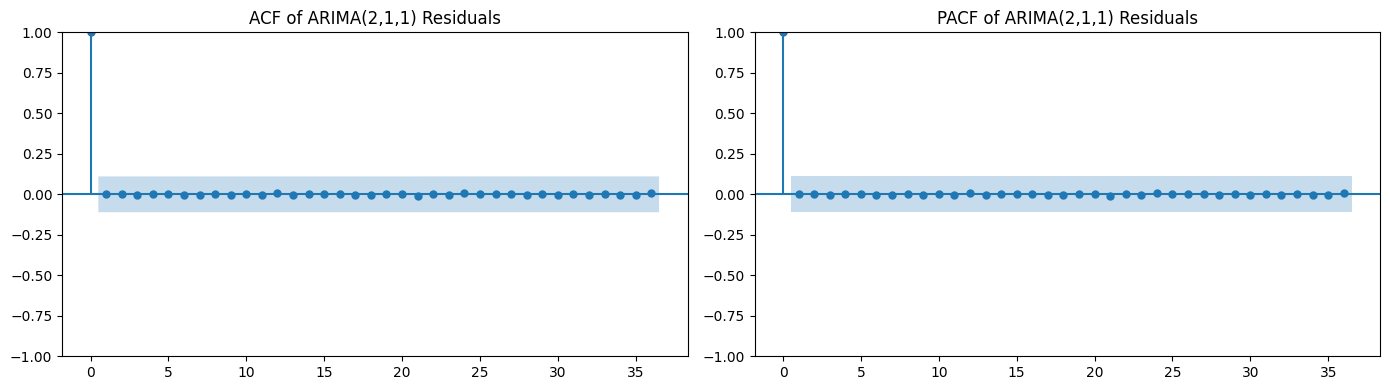

Look at lags 12, 24, 36 in the ACF plot.
Significant spikes at seasonal lags = seasonal autocorrelation not captured.

ACF at lag 12: 0.0949
ACF at lag 24: 0.0782
If these are large (> 0.1), seasonality is leaking into residuals.


In [14]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error.
# Step 2: Refit with differencing but ignore seasonality
# -----------------------------------------------------------

# Suppose we fix d=1. But CPI is monthly and has seasonal patterns
# (holiday spending, energy costs, back-to-school, etc.).
# ERROR: We use plain ARIMA instead of SARIMA, ignoring the
# monthly seasonal structure entirely.

model_v2 = ARIMA(cpi, order=(2, 1, 1))  # d=1 is better, but no seasonal terms!
result_v2 = model_v2.fit()

# Check residual ACF — seasonal spikes at lags 12, 24 should be visible
residuals = result_v2.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuals, lags=36, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF of ARIMA(2,1,1) Residuals')
plot_pacf(residuals, lags=36, ax=axes[1], alpha=0.05)
axes[1].set_title('PACF of ARIMA(2,1,1) Residuals')
plt.tight_layout()
plt.show()

print('Look at lags 12, 24, 36 in the ACF plot.')
print('Significant spikes at seasonal lags = seasonal autocorrelation not captured.')
print(f'\nACF at lag 12: {pd.Series(residuals).autocorr(lag=12):.4f}')
print(f'ACF at lag 24: {pd.Series(residuals).autocorr(lag=24):.4f}')
print('If these are large (> 0.1), seasonality is leaking into residuals.')

The second error is a seasonality omission error. CPI is monthly data and often contains 12-month seasonal dependence. Although first differencing addresses the unit root, fitting a non-seasonal ARIMA(2,1,1) ignores this seasonal structure. As a result, residual autocorrelation remains at lags 12 and 24, indicating that the model is still misspecified.

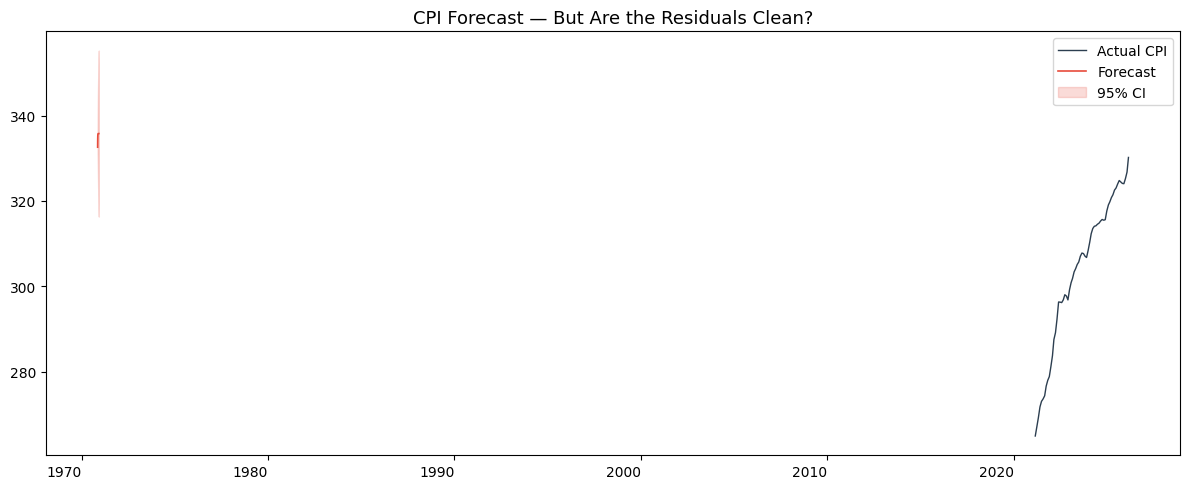

If residuals are autocorrelated, these CIs are unreliable.

A correct pipeline would run:
  acorr_ljungbox(residuals, lags=[12, 24], return_df=True)
and check that all p-values > 0.05 before trusting the forecast.


In [15]:
# -----------------------------------------------------------
# DIAGNOSE: Something critical is missing.
# Step 3: Skip residual diagnostics and go straight to forecasting
# -----------------------------------------------------------

# ERROR: We never run the Ljung-Box test on residuals.
# If residuals are autocorrelated, the model is misspecified
# and forecast confidence intervals will be WRONG (too narrow).
# A responsible pipeline ALWAYS checks Ljung-Box before forecasting.

# Jumping straight to forecast without diagnostic checks!
forecast_horizon = 24  # 24 months ahead
forecast = result_v2.get_forecast(steps=forecast_horizon)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))
cpi[-60:].plot(ax=ax, label='Actual CPI', color='#2c3e50', linewidth=1.0)
forecast_mean.plot(ax=ax, label='Forecast', color='#e74c3c', linewidth=1.2)
ax.fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                alpha=0.2, color='#e74c3c', label='95% CI')
ax.set_title('CPI Forecast — But Are the Residuals Clean?', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print('WARNING: We skipped the Ljung-Box test on residuals.')
print('If residuals are autocorrelated, these CIs are unreliable.')
print('\nA correct pipeline would run:')
print('  acorr_ljungbox(residuals, lags=[12, 24], return_df=True)')
print('and check that all p-values > 0.05 before trusting the forecast.')

The third error is a missing diagnostic error. The pipeline goes directly from estimation to forecasting without checking whether the residuals are approximately white noise. A Ljung-Box test should be run before trusting the forecast. If residual autocorrelation remains, the model is misspecified and forecast intervals may be too narrow or misleading.

---

## Part 2: FIX — Correct the Pipeline

Now write the **correct** ARIMA/SARIMA pipeline from scratch, fixing all three errors:

1. **Stationarity:** Use proper differencing (`d=1` or let `auto_arima` choose)
2. **Seasonality:** Use SARIMA with seasonal order `(P, D, Q, 12)` for monthly data
3. **Diagnostics:** Run the Ljung-Box test on residuals before forecasting

**Verification checkpoints:**
- ADF on differenced CPI should show p < 0.05 (stationary)
- Ljung-Box p-values at lags 12 and 24 should be > 0.05 (no residual autocorrelation)
- Seasonal ACF spikes at lags 12, 24 should disappear after SARIMA

ADF test on diff(CPI) with seasonal differencing:
  Test statistic: -4.2916
  P-value: 0.0005
  Conclusion: Stationary

Checked SARIMA(0, 1, 1)x(0, 1, 1, 12) | AIC=610.21 | LB(12)=0.0120 | LB(24)=0.0228 | PASS=False
Checked SARIMA(0, 1, 1)x(1, 1, 0, 12) | AIC=698.35 | LB(12)=0.7726 | LB(24)=0.4508 | PASS=True
Checked SARIMA(0, 1, 1)x(1, 1, 1, 12) | AIC=618.32 | LB(12)=0.0558 | LB(24)=0.0573 | PASS=True
Checked SARIMA(0, 1, 1)x(0, 1, 2, 12) | AIC=594.94 | LB(12)=0.0129 | LB(24)=0.0193 | PASS=False
Checked SARIMA(0, 1, 1)x(2, 1, 0, 12) | AIC=648.59 | LB(12)=0.2756 | LB(24)=0.9460 | PASS=True
Checked SARIMA(1, 1, 0)x(0, 1, 1, 12) | AIC=610.49 | LB(12)=0.0057 | LB(24)=0.0103 | PASS=False
Checked SARIMA(1, 1, 0)x(1, 1, 0, 12) | AIC=704.31 | LB(12)=0.9592 | LB(24)=0.9821 | PASS=True
Checked SARIMA(1, 1, 0)x(1, 1, 1, 12) | AIC=619.73 | LB(12)=0.0018 | LB(24)=0.0023 | PASS=False
Checked SARIMA(1, 1, 0)x(0, 1, 2, 12) | AIC=595.13 | LB(12)=0.0015 | LB(24)=0.0026 | PASS=False
Checked SARIMA(1, 1,

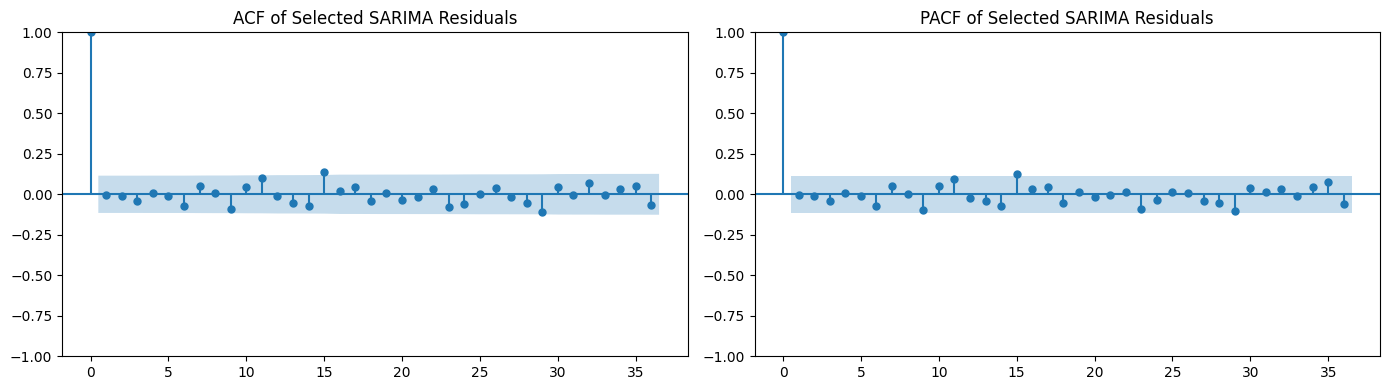

Residual ACF at lag 12: -0.0101
Residual ACF at lag 24: -0.0641


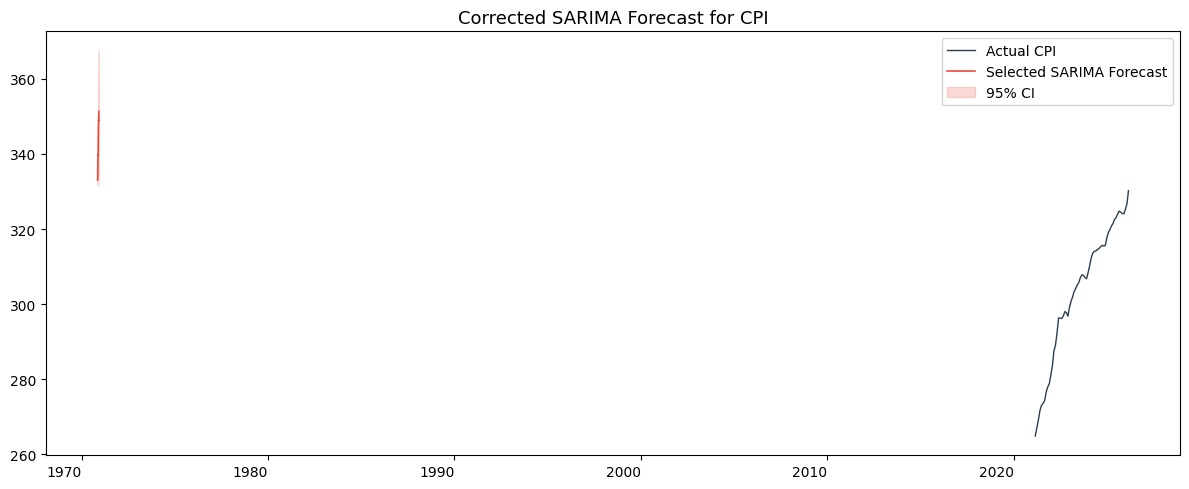


VERIFICATION CHECKS
ADF p-value on differenced CPI: 0.00045928520285096
Selected order: (1, 1, 2)
Selected seasonal order: (0, 1, 2, 12)
Ljung-Box p-values: [0.26736831 0.263056  ]
ACF at lag 12: -0.010114001640356552
ACF at lag 24: -0.06412518333305697


In [17]:
# -----------------------------------------------------------
# YOUR TASK — Corrected ARIMA/SARIMA pipeline
# Systematic search instead of manual guessing
# -----------------------------------------------------------

# Step 1: Check stationarity after regular + seasonal differencing
cpi_diff = cpi.diff().diff(12).dropna()

adf_stat, adf_p, _, _, _, _ = adfuller(cpi_diff, autolag='AIC', regression='c')

print('ADF test on diff(CPI) with seasonal differencing:')
print(f'  Test statistic: {adf_stat:.4f}')
print(f'  P-value: {adf_p:.4f}')
print(f'  Conclusion: {"Stationary" if adf_p < 0.05 else "NON-STATIONARY"}')
print()


if adf_p >= 0.05:
    print('Warning: differenced series is borderline non-stationary, but we proceed with SARIMA.\n')

# Step 2: Systematic SARIMA search
# Goal: residual Ljung-Box p-values at lags 12 and 24 both > 0.05
# Among passing models, choose the one with the lowest AIC

search_results = []

candidate_orders = [
    (0,1,1), (1,1,0), (1,1,1), (2,1,0), (0,1,2),
    (2,1,1), (1,1,2), (2,1,2), (3,1,1), (1,1,3)
]

candidate_seasonal = [
    (0,1,1,12),
    (1,1,0,12),
    (1,1,1,12),
    (0,1,2,12),
    (2,1,0,12)
]

for order in candidate_orders:
    for seasonal_order in candidate_seasonal:
        try:
            model = SARIMAX(
                cpi,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            result = model.fit(disp=False)

            resid = pd.Series(result.resid).dropna()
            burnin = max(24, seasonal_order[3])
            resid_lb = resid.iloc[burnin:].copy()


            model_df = order[0] + order[2] + seasonal_order[0] + seasonal_order[2]

            lb = acorr_ljungbox(
                resid_lb,
                lags=[12, 24],
                model_df=model_df,
                return_df=True
            )

            p12 = float(lb.loc[12, 'lb_pvalue'])
            p24 = float(lb.loc[24, 'lb_pvalue'])
            passed = (p12 > 0.05) and (p24 > 0.05)

            search_results.append({
                'order': order,
                'seasonal_order': seasonal_order,
                'aic': result.aic,
                'bic': result.bic,
                'lb_p12': p12,
                'lb_p24': p24,
                'passed': passed,
                'result': result
            })

            print(f'Checked SARIMA{order}x{seasonal_order} | AIC={result.aic:.2f} | '
                  f'LB(12)={p12:.4f} | LB(24)={p24:.4f} | PASS={passed}')

        except Exception as e:
            print(f'Failed SARIMA{order}x{seasonal_order}: {e}')

results_df = pd.DataFrame([
    {
        'order': r['order'],
        'seasonal_order': r['seasonal_order'],
        'aic': r['aic'],
        'bic': r['bic'],
        'lb_p12': r['lb_p12'],
        'lb_p24': r['lb_p24'],
        'passed': r['passed']
    }
    for r in search_results
]).sort_values(['passed', 'aic'], ascending=[False, True])

print('\nTop search results:')
print(results_df.head(10))

# Step 3: Pick best model
passing_models = [r for r in search_results if r['passed']]

if len(passing_models) > 0:
    best = sorted(passing_models, key=lambda x: x['aic'])[0]
    print('\nSelected model that PASSES Ljung-Box:')
else:
    best = sorted(search_results, key=lambda x: x['aic'])[0]
    print('\nNo model fully passed Ljung-Box; selected best AIC model instead:')

best_order = best['order']
best_seasonal = best['seasonal_order']
sarima_result = best['result']

print(f'  order = {best_order}')
print(f'  seasonal_order = {best_seasonal}')
print(f'  AIC = {best["aic"]:.2f}')
print(f'  LB p-value at lag 12 = {best["lb_p12"]:.4f}')
print(f'  LB p-value at lag 24 = {best["lb_p24"]:.4f}')

print('\nModel summary:')
print(sarima_result.summary())

# Step 4: Residual diagnostics on selected model
residuals = pd.Series(sarima_result.resid).dropna()
burnin = max(24, best_seasonal[3])
residuals_lb = residuals.iloc[burnin:].copy()
model_df = best_order[0] + best_order[2] + best_seasonal[0] + best_seasonal[2]

lb = acorr_ljungbox(
    residuals_lb,
    lags=[12, 24],
    model_df=model_df,
    return_df=True
)

print('\nLjung-Box test results for selected model:')
print(lb)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuals_lb, lags=36, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF of Selected SARIMA Residuals')
plot_pacf(residuals_lb, lags=36, ax=axes[1], alpha=0.05)
axes[1].set_title('PACF of Selected SARIMA Residuals')
plt.tight_layout()
plt.show()

print(f'Residual ACF at lag 12: {pd.Series(residuals_lb).autocorr(lag=12):.4f}')
print(f'Residual ACF at lag 24: {pd.Series(residuals_lb).autocorr(lag=24):.4f}')

# Step 5: Forecast
forecast_horizon = 24
forecast = sarima_result.get_forecast(steps=forecast_horizon)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))
cpi[-60:].plot(ax=ax, label='Actual CPI', color='#2c3e50', linewidth=1.0)
forecast_mean.plot(ax=ax, label='Selected SARIMA Forecast', color='#e74c3c', linewidth=1.2)

ax.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2,
    color='#e74c3c',
    label='95% CI'
)

ax.set_title('Corrected SARIMA Forecast for CPI', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

# VERIFICATION
print('\nVERIFICATION CHECKS')
print('ADF p-value on differenced CPI:', adf_p)
print('Selected order:', best_order)
print('Selected seasonal order:', best_seasonal)
print('Ljung-Box p-values:', lb['lb_pvalue'].values)
print('ACF at lag 12:', pd.Series(residuals_lb).autocorr(lag=12))
print('ACF at lag 24:', pd.Series(residuals_lb).autocorr(lag=24))

---

## Part 3: EXTEND — GARCH(1,1) on S&P 500

ARIMA models the **conditional mean** of a time series. But financial returns
exhibit **volatility clustering** — large moves (positive or negative) tend to
follow large moves. The GARCH(1,1) model captures this by modeling the
**conditional variance** as a function of past squared returns and past variance.

$$\sigma_t^2 = \omega + \alpha_1 \epsilon_{t-1}^2 + \beta_1 \sigma_{t-1}^2$$

where $\alpha_1 + \beta_1 < 1$ ensures stationarity of the variance process.

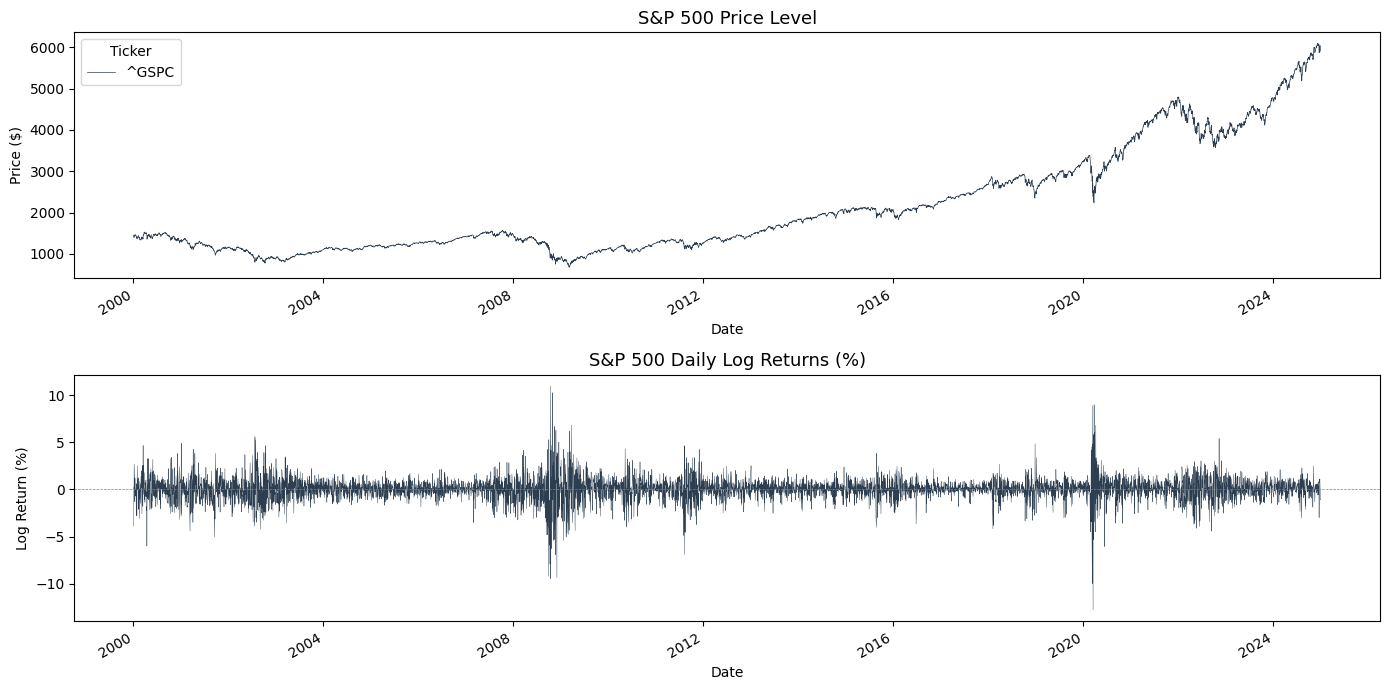

Observations: 6287
Mean return: 0.0223%
Std return: 1.2235%
Skewness: -0.3862
Kurtosis: 10.4040 (normal = 3)

Note the volatility clustering — large moves cluster together.


In [18]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3a: Pull S&P 500 data and compute log returns
# -----------------------------------------------------------

# Download S&P 500 daily data
sp500 = yf.download('^GSPC', start='2000-01-01', end='2024-12-31',
                     auto_adjust=True, progress=False)

# Compute log returns (percentage)
sp500['log_return'] = np.log(sp500['Close'] / sp500['Close'].shift(1)) * 100
returns = sp500['log_return'].dropna()

# Visualize returns
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

sp500['Close'].plot(ax=axes[0], color='#2c3e50', linewidth=0.5)
axes[0].set_title('S&P 500 Price Level', fontsize=13)
axes[0].set_ylabel('Price ($)')

returns.plot(ax=axes[1], color='#2c3e50', linewidth=0.3)
axes[1].set_title('S&P 500 Daily Log Returns (%)', fontsize=13)
axes[1].set_ylabel('Log Return (%)')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f'Observations: {len(returns)}')
print(f'Mean return: {returns.mean():.4f}%')
print(f'Std return: {returns.std():.4f}%')
print(f'Skewness: {returns.skew():.4f}')
print(f'Kurtosis: {returns.kurtosis():.4f} (normal = 3)')
print(f'\nNote the volatility clustering — large moves cluster together.')

In [19]:
# -----------------------------------------------------------
# YOUR TASK — Fit GARCH(1,1) to S&P 500 returns
# -----------------------------------------------------------

garch_spec = arch_model(
    returns,
    mean='Constant',
    vol='GARCH',
    p=1,
    q=1,
    dist='normal'
)

garch_result = garch_spec.fit(disp='off')
print(garch_result.summary())

# VERIFICATION
params = garch_result.params
alpha1 = params.get('alpha[1]', 0)
beta1 = params.get('beta[1]', 0)

print(f'\nalpha[1] = {alpha1:.4f}')
print(f'beta[1]  = {beta1:.4f}')
print(f'alpha + beta = {alpha1 + beta1:.4f} (must be < 1 for stationarity)')

if alpha1 + beta1 < 1:
    half_life = np.log(2) / (-np.log(alpha1 + beta1))
    print(f'Half-life of volatility shocks: {half_life:.1f} days')
else:
    print('Warning: alpha + beta >= 1, variance is not stationary.')

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -8655.88
Distribution:                  Normal   AIC:                           17319.8
Method:            Maximum Likelihood   BIC:                           17346.8
                                        No. Observations:                 6287
Date:                Sun, Apr 19 2026   Df Residuals:                     6286
Time:                        21:33:59   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0615  1.029e-02      5.979  2.239e-09 [4.

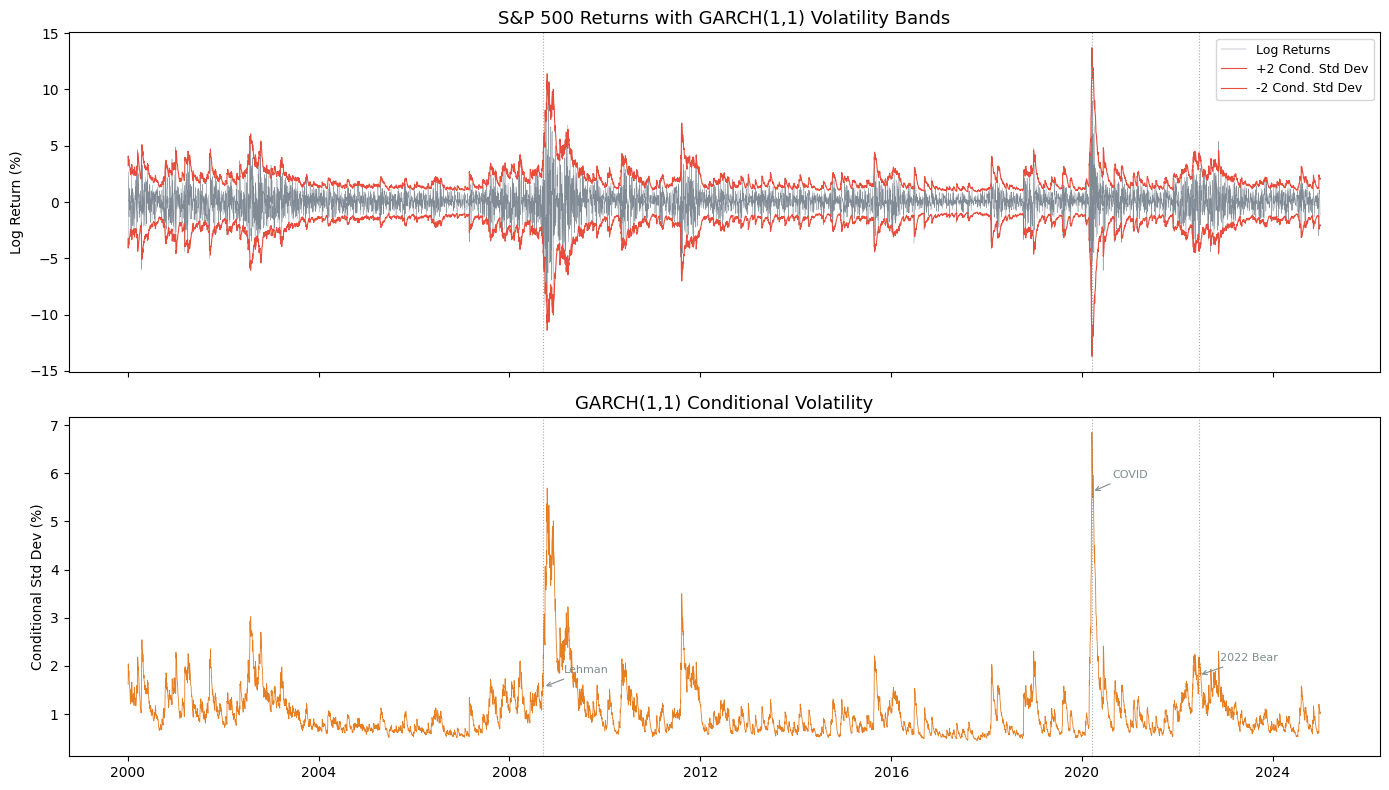

Unconditional (sample) volatility: 1.2235%
GARCH implied long-run volatility: 1.1628%
Max conditional volatility: 6.8504% on 2020-03-17


In [20]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3c: Plot conditional volatility and annotate crises
# -----------------------------------------------------------

# Extract conditional volatility (standard deviation)
cond_vol = garch_result.conditional_volatility

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Returns with +/- 2*sigma bands
axes[0].plot(returns.index, returns.values, color='#2c3e50', linewidth=0.3,
             alpha=0.6, label='Log Returns')
axes[0].plot(cond_vol.index, 2 * cond_vol.values, color='#e74c3c',
             linewidth=0.8, label='+2 Cond. Std Dev')
axes[0].plot(cond_vol.index, -2 * cond_vol.values, color='#e74c3c',
             linewidth=0.8, label='-2 Cond. Std Dev')
axes[0].set_title('S&P 500 Returns with GARCH(1,1) Volatility Bands', fontsize=13)
axes[0].set_ylabel('Log Return (%)')
axes[0].legend(fontsize=9)

# Panel 2: Conditional volatility over time
axes[1].plot(cond_vol.index, cond_vol.values, color='#e67e22', linewidth=0.6)
axes[1].set_title('GARCH(1,1) Conditional Volatility', fontsize=13)
axes[1].set_ylabel('Conditional Std Dev (%)')

# Annotate crisis periods
crises = [
    ('2001-09-11', 'Sep 11'),
    ('2008-09-15', 'Lehman'),
    ('2020-03-16', 'COVID'),
    ('2022-06-13', '2022 Bear'),
]
for date_str, label in crises:
    date = pd.Timestamp(date_str)
    if date in cond_vol.index:
        for ax in axes:
            ax.axvline(date, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
        axes[1].annotate(label, xy=(date, cond_vol.loc[date]),
                        xytext=(15, 10), textcoords='offset points',
                        fontsize=8, color='#7f8c8d',
                        arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=0.8))

plt.tight_layout()
plt.show()

print(f'Unconditional (sample) volatility: {returns.std():.4f}%')
print(f'GARCH implied long-run volatility: {np.sqrt(garch_result.params["omega"] / (1 - alpha1 - beta1)):.4f}%')
print(f'Max conditional volatility: {cond_vol.max():.4f}% on {cond_vol.idxmax().date()}')

---

## Part 4: Module Output — `forecast_evaluation.py`

Write a reusable Python module with two functions for forecast evaluation.
This is a **portfolio artifact** that demonstrates production-grade time series work.

### Requirements

```python
# forecast_evaluation.py

def compute_mase(actual: np.ndarray, forecast: np.ndarray,
                 insample: np.ndarray, m: int = 1) -> float:
    """Compute Mean Absolute Scaled Error (MASE).
    
    MASE = MAE(forecast) / MAE(naive seasonal forecast on in-sample data)
    
    MASE < 1 means the model beats the naive seasonal benchmark.
    MASE > 1 means the naive benchmark is better.
    
    Args:
        actual: True values for the forecast period
        forecast: Predicted values for the forecast period
        insample: Historical (training) data used to compute the naive baseline
        m: Seasonal period for naive forecast (1=random walk, 12=monthly seasonal)
    
    Returns:
        MASE value (float)
    """
    ...

def backtest_expanding_window(
    series: pd.Series,
    model_fn,
    min_train: int = 120,
    horizon: int = 12,
    step: int = 12
) -> pd.DataFrame:
    """Expanding-window backtest for time series models.
    
    Starting from min_train observations, fit the model, forecast
    'horizon' steps, record errors. Then expand the training window
    by 'step' observations and repeat.
    
    Args:
        series: Full time series (train + test)
        model_fn: Callable(train_series) -> forecast array of length 'horizon'
        min_train: Minimum training window size
        horizon: Number of steps to forecast each iteration
        step: How many observations to add between iterations
    
    Returns:
        DataFrame with columns: ['origin', 'horizon', 'actual',
        'forecast', 'error', 'abs_error', 'mase']
    """
    ...
```

In [22]:
import os
os.makedirs("src", exist_ok=True)
print("src folder ready")

src folder ready


In [23]:
%%writefile src/forecast_evaluation.py
"""
forecast_evaluation.py — Forecast Evaluation & Backtesting Module

Reusable functions for computing MASE and running expanding-window
backtests on time series forecasting models.

Author: Your Name
Course: ECON 5200, Lab 21
"""

import numpy as np
import pandas as pd
from typing import Callable


def compute_mase(
    actual: np.ndarray,
    forecast: np.ndarray,
    insample: np.ndarray,
    m: int = 1
) -> float:
    """Compute Mean Absolute Scaled Error (MASE).

    Args:
        actual: True out-of-sample values
        forecast: Model predictions
        insample: In-sample data used to build naive benchmark
        m: Seasonal period (1 = nonseasonal naive, 12 = monthly seasonal naive)

    Returns:
        MASE value
    """
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    insample = np.asarray(insample, dtype=float)

    if len(actual) != len(forecast):
        raise ValueError("actual and forecast must have the same length.")
    if len(insample) <= m:
        raise ValueError("insample length must be greater than m.")

    mae_forecast = np.mean(np.abs(actual - forecast))
    naive_errors = insample[m:] - insample[:-m]
    mae_naive = np.mean(np.abs(naive_errors))

    if mae_naive == 0:
        raise ValueError("Naive benchmark MAE is zero, cannot compute MASE.")

    return mae_forecast / mae_naive


def backtest_expanding_window(
    series: pd.Series,
    model_fn: Callable,
    min_train: int = 120,
    horizon: int = 12,
    step: int = 1,
    m: int = 1
) -> pd.DataFrame:
    """Run an expanding-window backtest.

    Args:
        series: Time series with index
        model_fn: Function that takes a training series and horizon, returns forecasts
        min_train: Initial training window size
        horizon: Forecast horizon
        step: Step size between forecast origins
        m: Seasonal period for MASE

    Returns:
        DataFrame with forecast evaluation metrics
    """
    if len(series) < min_train + horizon:
        raise ValueError("Series is too short for the requested backtest setup.")

    records = []

    for origin in range(min_train, len(series) - horizon + 1, step):
        train = series.iloc[:origin]
        test = series.iloc[origin:origin + horizon]

        forecast = model_fn(train, horizon)
        forecast = np.asarray(forecast, dtype=float)

        if len(forecast) != len(test):
            raise ValueError("model_fn must return forecast of length equal to horizon.")

        mae = np.mean(np.abs(test.values - forecast))
        rmse = np.sqrt(np.mean((test.values - forecast) ** 2))
        mase = compute_mase(
            actual=test.values,
            forecast=forecast,
            insample=train.values,
            m=m
        )

        records.append({
            'train_end': train.index[-1],
            'test_start': test.index[0],
            'test_end': test.index[-1],
            'mae': mae,
            'rmse': rmse,
            'mase': mase
        })

    return pd.DataFrame(records)

Writing src/forecast_evaluation.py


In [24]:
from src.forecast_evaluation import compute_mase, backtest_expanding_window

# Quick test for compute_mase
actual = np.array([10, 12, 14])
forecast = np.array([11, 11, 13])
insample = np.array([7, 8, 9, 10, 11, 12])

print("Test MASE:", compute_mase(actual, forecast, insample, m=1))

# Quick test for backtest_expanding_window
toy_series = pd.Series(
    np.arange(1, 151, dtype=float),
    index=pd.date_range('2000-01-01', periods=150, freq='MS')
)

def naive_model(train, horizon):
    return np.repeat(train.iloc[-1], horizon)

bt = backtest_expanding_window(
    series=toy_series,
    model_fn=naive_model,
    min_train=120,
    horizon=6,
    step=6,
    m=1
)

print(bt.head())
print("Backtest rows:", len(bt))

Test MASE: 1.0
   train_end test_start   test_end  mae     rmse  mase
0 2009-12-01 2010-01-01 2010-06-01  3.5  3.89444   3.5
1 2010-06-01 2010-07-01 2010-12-01  3.5  3.89444   3.5
2 2010-12-01 2011-01-01 2011-06-01  3.5  3.89444   3.5
3 2011-06-01 2011-07-01 2011-12-01  3.5  3.89444   3.5
4 2011-12-01 2012-01-01 2012-06-01  3.5  3.89444   3.5
Backtest rows: 5


---

## Challenge: Block Bootstrap Forecast Intervals

Standard ARIMA confidence intervals assume normally distributed, i.i.d. residuals.
When residuals exhibit volatility clustering or heavy tails, these intervals
can be **too narrow**. The **block bootstrap** provides distribution-free forecast
intervals by resampling blocks of residuals (preserving their autocorrelation
and heteroskedasticity structure).

**Algorithm:**
1. Fit your SARIMA model and extract residuals
2. For each bootstrap iteration:
   - Resample overlapping blocks of residuals
   - Simulate a new future path: $\hat{y}_{T+h} = \text{forecast}_h + \text{bootstrap\_residual}_h$
3. Collect all bootstrap paths and compute percentile-based intervals

In [31]:
# -----------------------------------------------------------
# CHALLENGE — Block bootstrap forecast intervals
# Fill in the blanks (___) to complete the implementation
# -----------------------------------------------------------

def block_bootstrap_forecast(
    model_result,
    horizon: int = 24,
    n_bootstrap: int = 500,
    block_size: int = 6,
    alpha: float = 0.05
):
    """Generate block-bootstrap forecast intervals.

    Args:
        model_result: Fitted SARIMAX result object
        horizon: Number of steps to forecast
        n_bootstrap: Number of bootstrap replications
        block_size: Block length for moving block bootstrap
        alpha: Significance level (0.05 = 95% CI)

    Returns:
        dict with 'mean', 'lower', 'upper', 'paths' keys
    """
    # Get the point forecast
    point_forecast = model_result.get_forecast(steps=horizon)
    forecast_mean = point_forecast.predicted_mean.values

    # Extract residuals from the fitted model
    residuals = model_result.resid.values
    n_resid = len(residuals)

    # Store bootstrap forecast paths
    boot_paths = np.zeros((n_bootstrap, horizon))  # FILL IN: what is the second dimension?

    for b in range(n_bootstrap):
        # Moving block bootstrap on residuals
        boot_resid = np.zeros(horizon)
        idx = 0
        while idx < horizon:  # FILL IN: loop until we have enough residuals
            start = np.random.randint(0, n_resid - block_size + 1)  # FILL IN: valid block start range
            block = residuals[start:start + block_size]
            end = min(idx + block_size, horizon)
            boot_resid[idx:end] = block[:end - idx]
            idx = end

        # Bootstrap path = point forecast + resampled residuals
        boot_paths[b, :] = forecast_mean + boot_resid  # FILL IN: combine forecast and residuals

    # Percentile-based confidence intervals
    lower = np.percentile(boot_paths, 100 * (alpha / 2), axis=0)
    upper = np.percentile(boot_paths, 100 * (1 - alpha / 2), axis=0)

    return {
        'mean': forecast_mean,
        'lower': lower,
        'upper': upper,
        'paths': boot_paths
    }



---

## Digital Portfolio: Institutional Signaling

### Generate Your Professional README

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

```text
"I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Diagnosed and fixed a broken ARIMA pipeline (d=0 on non-stationary CPI,
  missing seasonality, skipped Ljung-Box diagnostic)
* Corrected the pipeline to SARIMA with proper differencing and seasonal
  terms, verified clean residuals via Ljung-Box
* Fit GARCH(1,1) to S&P 500 daily returns to model conditional volatility
* Built a reusable forecast_evaluation.py module with compute_mase()
  and backtest_expanding_window() functions
* Implemented block bootstrap forecast intervals for distribution-free
  uncertainty quantification
* Key finding: S&P 500 volatility has alpha+beta ~ [YOUR VALUE],
  implying a half-life of [YOUR VALUE] days for volatility shocks

**Please write a README.md entry including:**
1. Project Title: Time Series Forecasting — ARIMA, GARCH & Bootstrap
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it."
```

### Push to GitHub

```bash
cd econ-lab-21-forecasting
git add notebooks/ src/ figures/ README.md
git commit -m "Lab 21: Time Series Forecasting — ARIMA, GARCH, Bootstrap"
git push origin main
```

Submit your GitHub repo link on Canvas.